📂 Caricamento dati finali...

🚀 Addestramento XGBoost con Feature Interaction...
✅ Modello addestrato!

🎯 ACCURATEZZA FINALE: 81.51%

📊 REPORT DETTAGLIATO:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89    159187
           1       0.37      0.78      0.50     21415

    accuracy                           0.82    180602
   macro avg       0.67      0.80      0.69    180602
weighted avg       0.89      0.82      0.84    180602



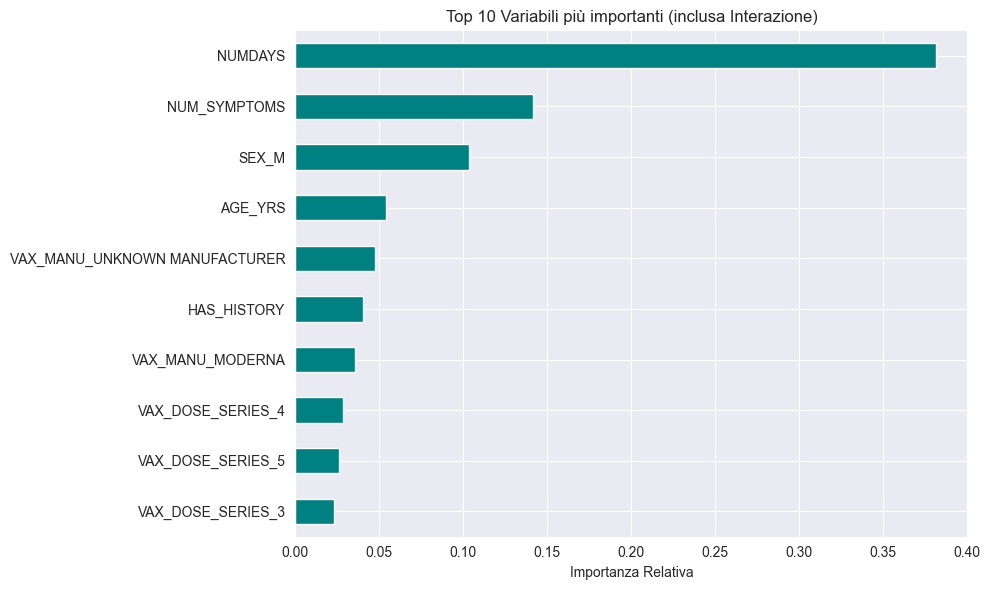

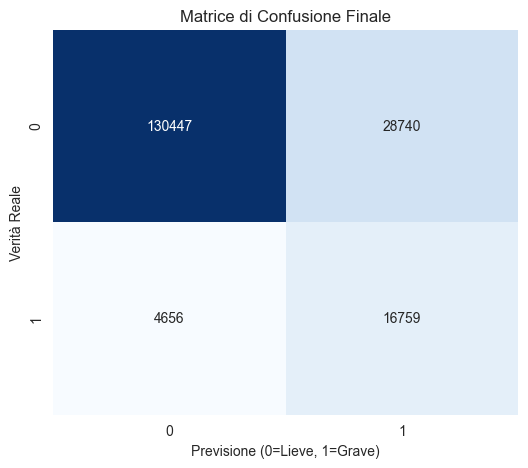

In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. CARICAMENTO DATI FINALI (Quelli con l'interazione)
print("📂 Caricamento dati finali...")
X_train = pd.read_csv('dataset/X_train_final.csv')
X_test = pd.read_csv('dataset/X_test_final.csv')
y_train = pd.read_csv('dataset/y_train_scaled.csv')
y_test = pd.read_csv('dataset/y_test_scaled.csv')

# 2. CALCOLO PESO BILANCIAMENTO
# Serve per gestire lo sbilanciamento (Teoria: Algorithm-level balancing)
conteggio = y_train.value_counts()
peso_bilanciamento = conteggio.iloc[0] / conteggio.iloc[1]

# 3. ADDESTRAMENTO MODELLO XGBOOST DEFINITIVO
print("\n🚀 Addestramento XGBoost con Feature Interaction...")
model_final = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=7,
    scale_pos_weight=peso_bilanciamento,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

model_final.fit(X_train, y_train.values.ravel())
print("✅ Modello addestrato!")

# 4. PREVISIONE E VALUTAZIONE
y_pred = model_final.predict(X_test)

print("\n" + "="*50)
print(f"🎯 ACCURATEZZA FINALE: {accuracy_score(y_test, y_pred):.2%}")
print("="*50)

print("\n📊 REPORT DETTAGLIATO:")
# Nota il Recall e la Precision per la classe 1 (Grave)
print(classification_report(y_test, y_pred))

# 5. ANALISI FEATURE IMPORTANCE (Vediamo se la tua intuizione era corretta)
plt.figure(figsize=(10, 6))
importanze = pd.Series(model_final.feature_importances_, index=X_train.columns).sort_values(ascending=True)
importanze.tail(10).plot(kind='barh', color='teal')
plt.title('Top 10 Variabili più importanti (inclusa Interazione)')
plt.xlabel('Importanza Relativa')
plt.tight_layout()
plt.show()

# 6. MATRICE DI CONFUSIONE
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Previsione (0=Lieve, 1=Grave)')
plt.ylabel('Verità Reale')
plt.title('Matrice di Confusione Finale')
plt.show()